# Alternative Tokenisation Comparison: CountVectorizer vs Q1 Methods

1. Python `split()`
2. Regular expression `re.findall(r'\b[a-zA-Z]+\b', text)`
3. NLTK `word_tokenize()`
4. Scikit-learn `CountVectorizer` (alternative approach)

> **Fair-comparison note:** The `CountVectorizer` removes English stop words and creates both unigrams and bigrams. Therefore, its total generated feature count is not directly comparable with the raw token counts from the other methods. A tokenisation-only CountVectorizer baseline is also included for a like-for-like unigram comparison.

In [1]:
# Imports and display settings
import re
import string
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer

pd.set_option("display.max_colwidth", 100)
plt.style.use("seaborn-v0_8-whitegrid")

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [2]:
# Locate Data_1.txt whether the notebook is run from its own folder or the TXSA project root
candidate_paths = [
    Path("Data_1.txt"),
    Path("source/TSXA/Q5_sklearn_count_vectorizer/Data_1.txt"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Data_1.txt was not found in the expected locations.")

text = data_path.read_text(encoding="utf-8")

print(f"Loaded: {data_path.resolve()}")
print(f"Characters: {len(text)}")
print("\nRaw text:\n")
print(text)

Loaded: C:\Users\ggshe\OneDrive - Asia Pacific University of Technology And Innovation (APU)\APU - Year 3\TXSA\source\TSXA\Q5_sklearn_count_vectorizer\Data_1.txt
Characters: 524

Raw text:

Classification is the task of choosing the correct class label for a given input. In basic
classification tasks, each input is considered in isolation from all other inputs, and the set of labels is defined in advance. The basic classification task has a number of interesting variants. For example, in multiclass classification, each instance may be assigned multiple labels; in open-class classification, the set of labels is not defined in advance; and in sequence classification, a list of inputs are jointly classified.


## 1. Implement all four approaches

Two CountVectorizer configurations are used:

- **CV fair baseline:** lowercase unigrams without stop-word removal. This isolates CountVectorizer's default tokenisation for a fair comparison.
- **CV student configuration:** the exact alternative approach, with English stop-word removal and `ngram_range=(1, 2)`.

In [3]:
# Group Q1 methods
tokens_split = text.split()
tokens_regex = re.findall(r"\b[a-zA-Z]+\b", text)
tokens_nltk = word_tokenize(text)

# CountVectorizer tokenisation-only baseline for a fair unigram comparison
cv_baseline = CountVectorizer(
    lowercase=True,
    stop_words=None,
    ngram_range=(1, 1),
)
tokens_cv_baseline = cv_baseline.build_analyzer()(text)

# Student's exact alternative configuration
cv_student = CountVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1,
)
X_student = cv_student.fit_transform([text])
tokens_cv_student = cv_student.build_analyzer()(text)
feature_names = cv_student.get_feature_names_out()
feature_counts = X_student.toarray()[0]

cv_student_unigrams = [token for token in tokens_cv_student if " " not in token]
cv_student_bigrams = [token for token in tokens_cv_student if " " in token]

print("Tokenisation completed successfully.")

Tokenisation completed successfully.


In [4]:
# Show representative output without printing an unnecessarily long list
sample_df = pd.DataFrame({
    "Method": [
        "split()",
        "Regular expression",
        "NLTK word_tokenize()",
        "CountVectorizer baseline",
        "CountVectorizer student configuration",
    ],
    "First 20 tokens/features": [
        tokens_split[:20],
        tokens_regex[:20],
        tokens_nltk[:20],
        tokens_cv_baseline[:20],
        tokens_cv_student[:20],
    ],
})

display(sample_df)

,Method,First 20 tokens/features
0,split(),"[Classification, is, the, task, of, choosing, the, correct, class, label, for, a, given, input.,..."
1,Regular expression,"[Classification, is, the, task, of, choosing, the, correct, class, label, for, a, given, input, ..."
2,NLTK word_tokenize(),"[Classification, is, the, task, of, choosing, the, correct, class, label, for, a, given, input, ..."
3,CountVectorizer baseline,"[classification, is, the, task, of, choosing, the, correct, class, label, for, given, input, in,..."
4,CountVectorizer student configuration,"[classification, task, choosing, correct, class, label, given, input, basic, classification, tas..."


## 2. Quantitative comparison

The first four rows below compare unigram tokenisers. The final row describes the student's full feature-generation pipeline, whose total includes both unigram and bigram occurrences.

In [5]:
def count_punctuation_only(tokens):
    """Count tokens made entirely from punctuation characters."""
    return sum(bool(token) and all(char in string.punctuation for char in token) for token in tokens)


def count_attached_punctuation(tokens):
    """Count tokens that mix letters with leading or trailing punctuation."""
    return sum(
        any(char.isalpha() for char in token)
        and (token[0] in string.punctuation or token[-1] in string.punctuation)
        for token in tokens
    )


comparison_df = pd.DataFrame([
    {
        "Method": "split()",
        "Native output count": len(tokens_split),
        "Unique outputs": len(set(tokens_split)),
        "Punctuation-only tokens": count_punctuation_only(tokens_split),
        "Punctuation attached": count_attached_punctuation(tokens_split),
        "Lowercases": "No",
        "Removes stop words": "No",
        "Creates bigrams": "No",
    },
    {
        "Method": "Regular expression",
        "Native output count": len(tokens_regex),
        "Unique outputs": len(set(tokens_regex)),
        "Punctuation-only tokens": count_punctuation_only(tokens_regex),
        "Punctuation attached": count_attached_punctuation(tokens_regex),
        "Lowercases": "No",
        "Removes stop words": "No",
        "Creates bigrams": "No",
    },
    {
        "Method": "NLTK word_tokenize()",
        "Native output count": len(tokens_nltk),
        "Unique outputs": len(set(tokens_nltk)),
        "Punctuation-only tokens": count_punctuation_only(tokens_nltk),
        "Punctuation attached": count_attached_punctuation(tokens_nltk),
        "Lowercases": "No",
        "Removes stop words": "No",
        "Creates bigrams": "No",
    },
    {
        "Method": "CountVectorizer baseline",
        "Native output count": len(tokens_cv_baseline),
        "Unique outputs": len(set(tokens_cv_baseline)),
        "Punctuation-only tokens": count_punctuation_only(tokens_cv_baseline),
        "Punctuation attached": count_attached_punctuation(tokens_cv_baseline),
        "Lowercases": "Yes",
        "Removes stop words": "No",
        "Creates bigrams": "No",
    },
    {
        "Method": "CountVectorizer student configuration",
        "Native output count": len(tokens_cv_student),
        "Unique outputs": len(set(tokens_cv_student)),
        "Punctuation-only tokens": count_punctuation_only(tokens_cv_student),
        "Punctuation attached": count_attached_punctuation(tokens_cv_student),
        "Lowercases": "Yes",
        "Removes stop words": "Yes (English)",
        "Creates bigrams": "Yes",
    },
])

display(comparison_df)

,Method,Native output count,Unique outputs,Punctuation-only tokens,Punctuation attached,Lowercases,Removes stop words,Creates bigrams
0,split(),82,55,0,12,No,No,No
1,Regular expression,83,50,0,0,No,No,No
2,NLTK word_tokenize(),94,53,12,0,No,No,No
3,CountVectorizer baseline,80,45,0,0,Yes,No,No
4,CountVectorizer student configuration,89,69,0,0,Yes,Yes (English),Yes


## 3. Behaviour on important examples

These examples explain *why* the methods produce different results, rather than relying only on total token counts.

In [6]:
diagnostic_df = pd.DataFrame([
    {
        "Text feature": "Sentence punctuation: advance. / advance;",
        "split()": "Keeps advance. and advance; as different tokens",
        "Regex": "Returns advance and removes punctuation",
        "NLTK": "Returns advance plus separate . or ; tokens",
        "CountVectorizer": "Returns lowercase advance; count = 2",
    },
    {
        "Text feature": "Hyphenated compound: open-class",
        "split()": "Preserves open-class",
        "Regex": "Splits into open and class",
        "NLTK": "Preserves open-class",
        "CountVectorizer": "Splits into open and class; can add bigram open class",
    },
    {
        "Text feature": "Capitalisation: Classification / classification",
        "split()": "Preserves case, creating different forms",
        "Regex": "Preserves case, creating different forms",
        "NLTK": "Preserves case, creating different forms",
        "CountVectorizer": "Lowercases both to classification",
    },
    {
        "Text feature": "Common words: is, the, of, in",
        "split()": "Retains them",
        "Regex": "Retains them",
        "NLTK": "Retains them",
        "CountVectorizer": "Student configuration removes English stop words",
    },
    {
        "Text feature": "Numerical model input",
        "split()": "Tokens only",
        "Regex": "Tokens only",
        "NLTK": "Tokens only",
        "CountVectorizer": "Builds vocabulary and sparse count matrix directly",
    },
])

display(diagnostic_df)

,Text feature,split(),Regex,NLTK,CountVectorizer
0,Sentence punctuation: advance. / advance;,Keeps advance. and advance; as different tokens,Returns advance and removes punctuation,Returns advance plus separate . or ; tokens,Returns lowercase advance; count = 2
1,Hyphenated compound: open-class,Preserves open-class,Splits into open and class,Preserves open-class,Splits into open and class; can add bigram open class
2,Capitalisation: Classification / classification,"Preserves case, creating different forms","Preserves case, creating different forms","Preserves case, creating different forms",Lowercases both to classification
3,"Common words: is, the, of, in",Retains them,Retains them,Retains them,Student configuration removes English stop words
4,Numerical model input,Tokens only,Tokens only,Tokens only,Builds vocabulary and sparse count matrix directly


## 4. CountVectorizer vocabulary and word counts

Unlike the three Q1 methods, CountVectorizer does not stop at returning tokens. It creates a consistent vocabulary and a documentâ€“term count matrix that can be passed directly to a machine-learning model.

In [7]:
counts_df = pd.DataFrame({
    "Feature": feature_names,
    "Count": feature_counts,
})
counts_df["Feature type"] = counts_df["Feature"].str.contains(" ").map({False: "Unigram", True: "Bigram"})
counts_df = counts_df.sort_values(["Count", "Feature"], ascending=[False, True]).reset_index(drop=True)

print(f"Sparse matrix shape: {X_student.shape}")
print(f"Vocabulary size: {len(feature_names)}")
print("\nTop 20 features by frequency:")
display(counts_df.head(20))

print("Examples of bigrams generated across punctuation or removed stop words:")
boundary_examples = [
    feature for feature in ["input basic", "advance basic", "variants example", "labels open", "advance sequence"]
    if feature in set(feature_names)
]
print(boundary_examples)

Sparse matrix shape: (1, 69)
Vocabulary size: 69

Top 20 features by frequency:


,Feature,Count,Feature type
0,classification,6,Unigram
1,labels,3,Unigram
2,advance,2,Unigram
3,basic,2,Unigram
4,basic classification,2,Bigram
5,class,2,Unigram
6,classification task,2,Bigram
7,defined,2,Unigram
8,defined advance,2,Bigram
9,input,2,Unigram


Examples of bigrams generated across punctuation or removed stop words:
['input basic', 'advance basic', 'variants example', 'labels open', 'advance sequence']


## 5. Visual comparison

- **Chart A** is the fair raw-unigram comparison.
- **Chart B** separates unigram and bigram results from the student's exact configuration.
- **Chart C** shows the most frequent unigram features produced for machine learning.

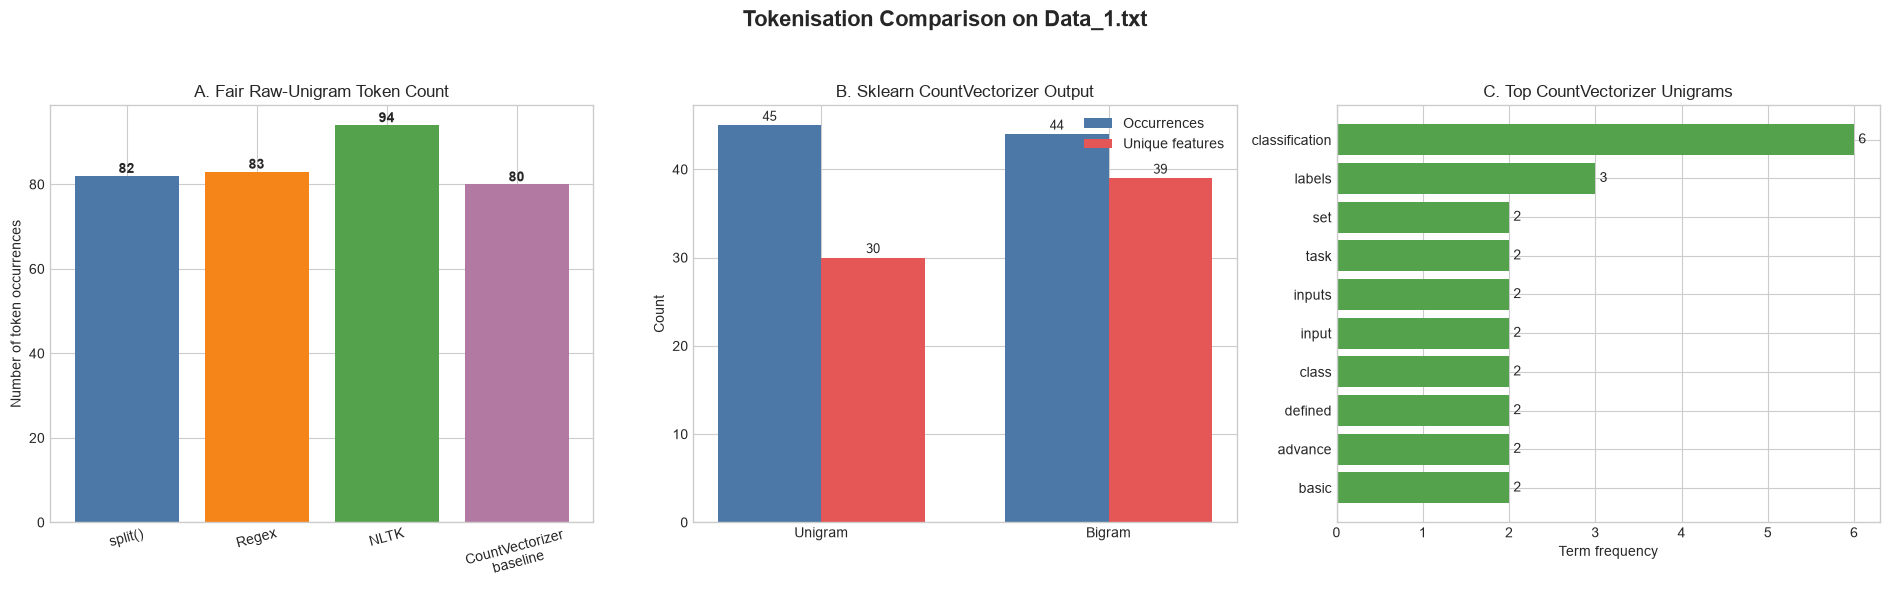

Saved combined chart to: Tokenization_Comparison_Charts.png


,Feature type,Occurrences,Unique features
0,Unigram,45,30
1,Bigram,44,39


In [8]:
# Prepare fair baseline counts
fair_methods = ["split()", "Regex", "NLTK", "CountVectorizer\nbaseline"]
fair_counts = [len(tokens_split), len(tokens_regex), len(tokens_nltk), len(tokens_cv_baseline)]

# Prepare CountVectorizer occurrence and unique-feature breakdown
cv_breakdown = pd.DataFrame({
    "Feature type": ["Unigram", "Bigram"],
    "Occurrences": [len(cv_student_unigrams), len(cv_student_bigrams)],
    "Unique features": [
        len(set(cv_student_unigrams)),
        len(set(cv_student_bigrams)),
    ],
})

# Prepare top unigram frequencies
top_unigrams = (
    counts_df[counts_df["Feature type"] == "Unigram"]
    .head(10)
    .sort_values("Count", ascending=True)
)

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# Chart A: fair raw-unigram token count
bars_a = axes[0].bar(fair_methods, fair_counts, color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"])
axes[0].set_title("A. Fair Raw-Unigram Token Count")
axes[0].set_ylabel("Number of token occurrences")
axes[0].tick_params(axis="x", rotation=15)
for bar, value in zip(bars_a, fair_counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, value + 0.7, str(value), ha="center", fontweight="bold")

# Chart B: exact CountVectorizer configuration
x_positions = range(len(cv_breakdown))
width = 0.36
bars_b1 = axes[1].bar(
    [x - width / 2 for x in x_positions],
    cv_breakdown["Occurrences"],
    width,
    label="Occurrences",
    color="#4C78A8",
)
bars_b2 = axes[1].bar(
    [x + width / 2 for x in x_positions],
    cv_breakdown["Unique features"],
    width,
    label="Unique features",
    color="#E45756",
)
axes[1].set_xticks(list(x_positions), cv_breakdown["Feature type"])
axes[1].set_title("B. Sklearn CountVectorizer Output")
axes[1].set_ylabel("Count")
axes[1].legend()
for bars in (bars_b1, bars_b2):
    for bar in bars:
        value = int(bar.get_height())
        axes[1].text(bar.get_x() + bar.get_width() / 2, value + 0.5, str(value), ha="center", fontsize=9)

# Chart C: top CountVectorizer unigrams
axes[2].barh(top_unigrams["Feature"], top_unigrams["Count"], color="#54A24B")
axes[2].set_title("C. Top CountVectorizer Unigrams")
axes[2].set_xlabel("Term frequency")
for index, value in enumerate(top_unigrams["Count"]):
    axes[2].text(value + 0.05, index, str(int(value)), va="center")

fig.suptitle("Tokenisation Comparison on Data_1.txt", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.94])
chart_path = "Tokenization_Comparison_Charts.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved combined chart to: {chart_path}")
display(cv_breakdown)

## 6. Compare and contrast the approaches

| Criterion | `split()` | Regex | NLTK `word_tokenize()` | CountVectorizer alternative |
|---|---|---|---|---|
| Basic operation | Splits only at whitespace | Extracts text matching a chosen pattern | Applies linguistically motivated tokenisation rules | Preprocesses, tokenises, optionally removes stop words, creates n-grams, and builds a count matrix |
| Punctuation | Remains attached to words | Removed by this pattern | Kept as separate tokens | Removed by the default token pattern |
| Case handling | Preserves case | Preserves case | Preserves case | Lowercases automatically in this configuration |
| Hyphenated `open-class` | Preserved | Split into `open` and `class` | Preserved | Split into `open` and `class`; the bigram `open class` is also created |
| Stop words | Retained | Retained | Retained | English stop words removed in the student configuration |
| Multi-word features | No | No | No | Yes, unigrams and bigrams |
| Numerical output for ML | No | No | No | Yes, a sparse documentâ€“term matrix |
| Main strength | Simplest and easiest to explain | Highly customisable pattern | Best linguistic detail among these four configurations | Best direct fit for bag-of-words text classification |
| Main limitation | Inconsistent vocabulary because punctuation remains attached | Can discard useful structure or split compounds | Requires extra preprocessing before most ML models | Loses punctuation/linguistic detail and can create misleading cross-boundary bigrams |

### Why CountVectorizer is better for this student's intended task

CountVectorizer is **better when the next step is count-based text classification or other bag-of-words machine learning**. It standardises case, removes the selected English stop words, produces consistent word counts, supports bigrams, builds a vocabulary, and returns a sparse numerical matrix. For example, `advance.` and `advance;` both become the same feature `advance`, whose count is 2. The bigrams also represent some local phrases, such as `class label`, `defined advance`, and `sequence classification`, which the three raw tokenisers do not create by themselves.

### Why CountVectorizer can be worse

CountVectorizer is **worse when punctuation, sentence boundaries, grammatical contractions, or the exact form of compound words is important**. Its default token pattern removes punctuation and splits `open-class` into `open` and `class`, whereas NLTK preserves `open-class` and keeps punctuation as separate tokens. It also normally ignores one-character tokens, so potentially meaningful items such as `I` or `a` are dropped. In this configuration, stop-word removal happens before bigram creation; therefore, some bigrams can cross punctuation or removed words. In the obtained output, examples include `input basic`, `variants example`, and `labels open`. These sequences are present in the feature matrix but are not necessarily meaningful phrases.

### Why CountVectorizer is also simply different

The approaches do not have exactly the same purpose. `split()`, regex, and NLTK mainly return token sequences. CountVectorizer is a larger feature-extraction pipeline: tokenisation is only one stage, followed by vocabulary construction and numerical counting. This is why the student's 89 generated feature occurrences cannot be treated as directly better than NLTK's 94 raw tokens. In the fair unigram-only baseline, CountVectorizer behaves similarly to the Q1 regex on this dataset, but it adds automatic lowercasing and direct vectorisation.

In [9]:
# Report-ready evidence summary generated from the actual output
advance_count = int(counts_df.loc[counts_df["Feature"] == "advance", "Count"].iloc[0])

print("VERIFIED RESULT SUMMARY")
print("=" * 72)
print(f"split() raw tokens                         : {len(tokens_split)}")
print(f"Regular-expression raw tokens             : {len(tokens_regex)}")
print(f"NLTK raw tokens                           : {len(tokens_nltk)}")
print(f"CountVectorizer fair-baseline raw tokens   : {len(tokens_cv_baseline)}")
print(f"CountVectorizer configured unigrams        : {len(cv_student_unigrams)}")
print(f"CountVectorizer configured bigrams         : {len(cv_student_bigrams)}")
print(f"CountVectorizer total feature occurrences  : {len(tokens_cv_student)}")
print(f"CountVectorizer unique vocabulary features : {len(feature_names)}")
print(f"Count of the normalised feature 'advance'  : {advance_count}")
print("=" * 72)

VERIFIED RESULT SUMMARY
split() raw tokens                         : 82
Regular-expression raw tokens             : 83
NLTK raw tokens                           : 94
CountVectorizer fair-baseline raw tokens   : 80
CountVectorizer configured unigrams        : 45
CountVectorizer configured bigrams         : 44
CountVectorizer total feature occurrences  : 89
CountVectorizer unique vocabulary features : 69
Count of the normalised feature 'advance'  : 2


## 7. Final judgement

**Overall verdict:** The CountVectorizer alternative is **better for preparing bag-of-words features for machine learning**, **worse for linguistically detailed tokenisation**, and **different in scope** because it performs vectorisation as well as tokenisation.

For this assignment, the most defensible conclusion is not that CountVectorizer is universally superior. NLTK remains more suitable when the objective is to preserve linguistic token boundaries and punctuation. CountVectorizer is more practical when the objective is to transform text directly into consistent numerical features for a classifier. If both strengths are required, CountVectorizer can also be customised with a different tokenizer rather than relying on its default token pattern.